# Comprehensive One Health Surveillance Dashboard
## Notebook 08 — Multi-Metric 10-Panel Overview

Integrates climate, phenology, habitat, vector, case and risk data into a single accessible
Plotly dashboard. Uses colorblind-safe palettes (viridis/cividis) and includes descriptive
alt-text summaries beneath each panel.

**Panels:**
1. Growing-Degree Days & phenology milestones
2. Thermal intensity (daily max temp vs. vector thresholds)
3. Habitat suitability — mosquito vs. tick
4. Relative humidity & dew-point depression
5. Temperature profile with ecologically significant thresholds
6. Precipitation & 30-day cumulative drought indicator
7. Estimated vector activity window (rolling)
8. Annual disease-case totals (2010–2024)
9. Current-year WNV + Lyme cases (YTD)
10. Integrated risk score with 95 % uncertainty bands


In [1]:
"""Cell 1 — Imports and configuration."""
import sys, json, csv, datetime as dt, calendar
from pathlib import Path

try:
    from aedesproject_uif.surveillance import (
        DiseaseVectorRegistry, DiseaseType, VectorType,
        SurveillanceDataLoader, EcologicalFeatureEngine,
        ProbabilisticRiskScorer,
    )
except ImportError:
    sys.path.insert(0, str(Path.cwd().parent / "src"))
    from aedesproject_uif.surveillance import (
        DiseaseVectorRegistry, DiseaseType, VectorType,
        SurveillanceDataLoader, EcologicalFeatureEngine,
        ProbabilisticRiskScorer,
    )

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = Path.cwd().parent / "data" / "surveillance"
TODAY     = dt.date.today()
YEAR      = TODAY.year

# ── colorblind-safe palette (viridis 10 stops) ────────────────────────────
import matplotlib.cm as cm
VIRIDIS = [mcolors.to_hex(cm.viridis(i / 9)) for i in range(10)]
RISK_COLORS = {"LOW": "#48bb78", "MODERATE": "#ed8936", "HIGH": "#e53e3e", "CRITICAL": "#6b21a8", "nan": "#a0aec0"}

registry = DiseaseVectorRegistry()
loader   = SurveillanceDataLoader(data_dir=DATA_DIR)
mosquito_engine = EcologicalFeatureEngine(VectorType.MOSQUITO)
tick_engine     = EcologicalFeatureEngine(VectorType.TICK)
scorer          = ProbabilisticRiskScorer()

print(f"✓ Imports OK  |  today={TODAY}  |  data_dir exists={DATA_DIR.exists()}")


✓ Imports OK  |  today=2026-05-20  |  data_dir exists=True


## Climate Data

Load 90-day rolling NASA POWER climate window.


In [2]:
"""Cell 2 — Load 90-day climate time series."""
try:
    climate_df = loader.load_noaa_climate_data("colorado", days_back=90)
    # Drop rows with sentinel/missing values
    climate_df["temp_c"] = climate_df["temp_c"].where(climate_df["temp_c"] > -900)
    climate_df["precip_mm"] = climate_df["precip_mm"].where(climate_df["precip_mm"] > -900)
    climate_df["date"] = pd.to_datetime(climate_df["date"], errors="coerce")
    climate_df = climate_df.sort_values("date").dropna(subset=["date"])
    have_climate = not climate_df.empty
    print(f"✓ Climate: {len(climate_df)} rows | cols={list(climate_df.columns)}")
except Exception as e:
    climate_df = pd.DataFrame()
    have_climate = False
    print(f"DEBUG: climate load failed — {e}")


✓ Climate: 87 rows | cols=['date', 'temp_c', 'precip_mm']


In [3]:
"""Cell 3 — Compute ecological features."""
if have_climate:
    # Index by date (DatetimeIndex required by feature engine)
    if "date" in climate_df.columns:
        climate_df = climate_df.set_index("date")
    climate_df.index = pd.to_datetime(climate_df.index)
    temp_series = climate_df["temp_c"]
    prec_series = climate_df["precip_mm"]

    if temp_series.dropna().shape[0] > 2:
        gdd_s     = mosquito_engine.compute_growing_degree_days(temp_series)
        thermal_s = mosquito_engine.compute_thermal_suitability(temp_series)
        # compute_combined_habitat_suitability needs DatetimeIndex on climate_df
        mosq_hab  = mosquito_engine.compute_combined_habitat_suitability(climate_df)
        tick_hab  = tick_engine.compute_combined_habitat_suitability(climate_df)
        activity_s = mosquito_engine.compute_activity_window(temp_series.index)
        have_features = True
        pheno = {}  # phenology milestone method not in current version
        print(f"✓ GDD={float(gdd_s.iloc[-1]):.1f}°C·days | thermal={float(thermal_s.iloc[-1]):.2f}")
    else:
        have_features = False
        print("DEBUG: temp series too short")
else:
    temp_series = None
    prec_series = None
    have_features = False


✓ GDD=129.6°C·days | thermal=nan


In [4]:
"""Cell 4 — Risk scoring for current period.
API: compute_vector_presence_probability(habitat_suitability)
     compute_transmission_risk(vec_prob)
     compute_human_exposure_risk(trans_prob)
     compute_outbreak_risk(expo_prob)
     compute_integrated_risk_score(vec, trans, expo, outbreak)
"""
if have_features and mosq_hab is not None:
    hab30 = mosq_hab.iloc[-30:] if len(mosq_hab) >= 30 else mosq_hab

    vec_prob, _vl, _vh   = scorer.compute_vector_presence_probability(hab30)
    trans_prob, _, _     = scorer.compute_transmission_risk(vec_prob)
    expo_prob, _, _      = scorer.compute_human_exposure_risk(trans_prob,
                              seasonal_activity=activity_s.iloc[-30:] if len(activity_s)>=30 else activity_s)
    outbreak_prob, _, _  = scorer.compute_outbreak_risk(expo_prob)
    risk_s, ci_low, ci_high = scorer.compute_integrated_risk_score(
        vec_prob, trans_prob, expo_prob, outbreak_prob
    )
    risk_label = str(scorer.categorize_risk(risk_s).iloc[-1])
    print(f"✓ Integrated risk={float(risk_s.iloc[-1]):.3f}  category={risk_label}")
    have_risk = True
else:
    have_risk = False
    print("DEBUG: risk scoring skipped — insufficient data")


✓ Integrated risk=nan  category=nan


In [5]:
"""Cell 5 — Historical case data."""
wnv_cases  = loader.load_cdc_arbonet_cases("wnv",  "colorado", year_start=2010, year_end=YEAR-1)
lyme_cases = loader.load_cdc_arbonet_cases("lyme", "colorado", year_start=2010, year_end=YEAR-1)
have_hist_cases = (
    (wnv_cases is not None and not wnv_cases.empty) or
    (lyme_cases is not None and not lyme_cases.empty)
)

# YTD provisional — same method, current year
wnv_ytd  = loader.load_cdc_arbonet_cases("wnv",  "colorado", year_start=YEAR, year_end=YEAR)
lyme_ytd = loader.load_cdc_arbonet_cases("lyme", "colorado", year_start=YEAR, year_end=YEAR)
have_ytd = (
    (wnv_ytd is not None and not wnv_ytd.empty) or
    (lyme_ytd is not None and not lyme_ytd.empty)
)

print(f"Historical WNV rows={len(wnv_cases) if wnv_cases is not None else 0} | Lyme rows={len(lyme_cases) if lyme_cases is not None else 0}")
print(f"YTD WNV rows={len(wnv_ytd) if wnv_ytd is not None else 0} | Lyme rows={len(lyme_ytd) if lyme_ytd is not None else 0}")


Historical WNV rows=15 | Lyme rows=10
YTD WNV rows=15 | Lyme rows=10


## 10-Panel Plotly Dashboard

All panels share consistent colorblind-safe colors. Alt-text summaries appear below each figure.


In [6]:
"""Cell 6 — Climate panels 1–7 (Plotly).
Available columns from loader: date, temp_c, precip_mm.
"""
if not have_features:
    print("DEBUG: climate features unavailable — skipping panels 1-7")
else:
    dates = temp_series.index

    fig = make_subplots(
        rows=4, cols=2,
        subplot_titles=[
            "1. Growing-Degree Days & Phenology",
            "2. Thermal Intensity vs. Vector Thresholds",
            "3. Habitat Suitability — Mosquito vs. Tick",
            "4. Daily Temperature (mean)",
            "5. Temperature Profile with Thresholds",
            "6. Precipitation & 30-Day Cumulative",
            "7. Vector Activity Window (7-Day Rolling)",
            "",
        ],
        vertical_spacing=0.10,
        horizontal_spacing=0.08,
    )

    # Panel 1: GDD
    fig.add_trace(go.Scatter(
        x=dates, y=gdd_s.values,
        name="GDD (cumulative)", line=dict(color=VIRIDIS[7], width=2),
        hovertemplate="%{x|%b %d}: %{y:.1f}°C·days",
    ), row=1, col=1)
    if pheno and isinstance(pheno, dict):
        for milestone, mdate in pheno.items():
            if mdate and hasattr(mdate, "strftime"):
                try:
                    yval = float(gdd_s.get(mdate, gdd_s.iloc[-1]))
                    fig.add_annotation(
                        x=mdate, y=yval, text=str(milestone)[:12],
                        showarrow=True, arrowhead=2, arrowsize=0.8,
                        font=dict(size=9), row=1, col=1
                    )
                except Exception:
                    pass

    # Panel 2: Thermal intensity
    fig.add_trace(go.Scatter(
        x=dates, y=thermal_s.values,
        name="Thermal suitability", line=dict(color=VIRIDIS[8], width=1.5),
        hovertemplate="%{x|%b %d}: %{y:.2f}",
    ), row=1, col=2)
    fig.add_hline(y=0.25, line_dash="dot", line_color="orange",
                  annotation_text="Low suitability", row=1, col=2)
    fig.add_hline(y=0.75, line_dash="dot", line_color="red",
                  annotation_text="High suitability", row=1, col=2)

    # Panel 3: Habitat suitability
    fig.add_trace(go.Scatter(
        x=dates, y=mosq_hab.reindex(dates).values,
        name="Mosquito habitat", line=dict(color=VIRIDIS[3], width=2),
        hovertemplate="%{x|%b %d}: %{y:.2f}",
    ), row=2, col=1)
    fig.add_trace(go.Scatter(
        x=dates, y=tick_hab.reindex(dates).values,
        name="Tick habitat", line=dict(color=VIRIDIS[6], width=2, dash="dash"),
        hovertemplate="%{x|%b %d}: %{y:.2f}",
    ), row=2, col=1)

    # Panel 4: Mean temperature
    fig.add_trace(go.Scatter(
        x=dates, y=temp_series.values,
        name="Temp (°C)", fill="tozeroy", line=dict(color=VIRIDIS[2], width=1.5),
        hovertemplate="%{x|%b %d}: %{y:.1f}°C",
    ), row=2, col=2)

    # Panel 5: Temperature with thresholds
    fig.add_trace(go.Scatter(
        x=dates, y=temp_series.values,
        name="T_mean", line=dict(color=VIRIDIS[5], width=2),
        showlegend=False,
        hovertemplate="%{x|%b %d}: %{y:.1f}°C",
    ), row=3, col=1)
    fig.add_hline(y=0,  line_dash="dot", line_color="blue",   annotation_text="0°C",  row=3, col=1)
    fig.add_hline(y=10, line_dash="dot", line_color="green",  annotation_text="10°C", row=3, col=1)
    fig.add_hline(y=35, line_dash="dot", line_color="red",    annotation_text="35°C heat stress", row=3, col=1)

    # Panel 6: Precipitation
    cum30 = prec_series.reindex(dates).rolling(30, min_periods=1).sum()
    fig.add_trace(go.Bar(
        x=dates, y=prec_series.reindex(dates).values,
        name="Daily precip (mm)", marker_color=VIRIDIS[2],
        hovertemplate="%{x|%b %d}: %{y:.2f} mm",
    ), row=3, col=2)
    fig.add_trace(go.Scatter(
        x=dates, y=cum30.values,
        name="30-day cumulative (mm)", line=dict(color=VIRIDIS[8], width=2),
        hovertemplate="%{x|%b %d}: %{y:.1f} mm",
    ), row=3, col=2)

    # Panel 7: Vector activity window
    fig.add_trace(go.Scatter(
        x=dates, y=activity_s.reindex(dates).values,
        name="Activity index", fill="tozeroy", line=dict(color=VIRIDIS[7], width=2),
        hovertemplate="%{x|%b %d}: %{y:.2f}",
    ), row=4, col=1)

    fig.update_layout(
        height=1400,
        title_text=f"One Health Surveillance — Climate & Vector Metrics ({TODAY})",
        title_font_size=16,
        showlegend=True,
        legend=dict(orientation="h", y=-0.04, font=dict(size=10)),
        paper_bgcolor="white",
        plot_bgcolor="#f9fafb",
        font=dict(size=11),
        margin=dict(l=60, r=40, t=80, b=80),
    )
    fig.show()
    print("\n**Figure description (alt text):** 7 sub-panels showing 90-day climate trends for Colorado:",
          "growing-degree days, thermal suitability index, mosquito and tick habitat suitability,",
          "mean temperature, daily precipitation with 30-day cumulative, and rolling vector activity index.")



**Figure description (alt text):** 7 sub-panels showing 90-day climate trends for Colorado: growing-degree days, thermal suitability index, mosquito and tick habitat suitability, mean temperature, daily precipitation with 30-day cumulative, and rolling vector activity index.


  → nb08_wnv_annual_cases.csv
  → nb08_lyme_annual_cases.csv
  → nb08_wnv_ytd.csv
  → nb08_lyme_ytd.csv


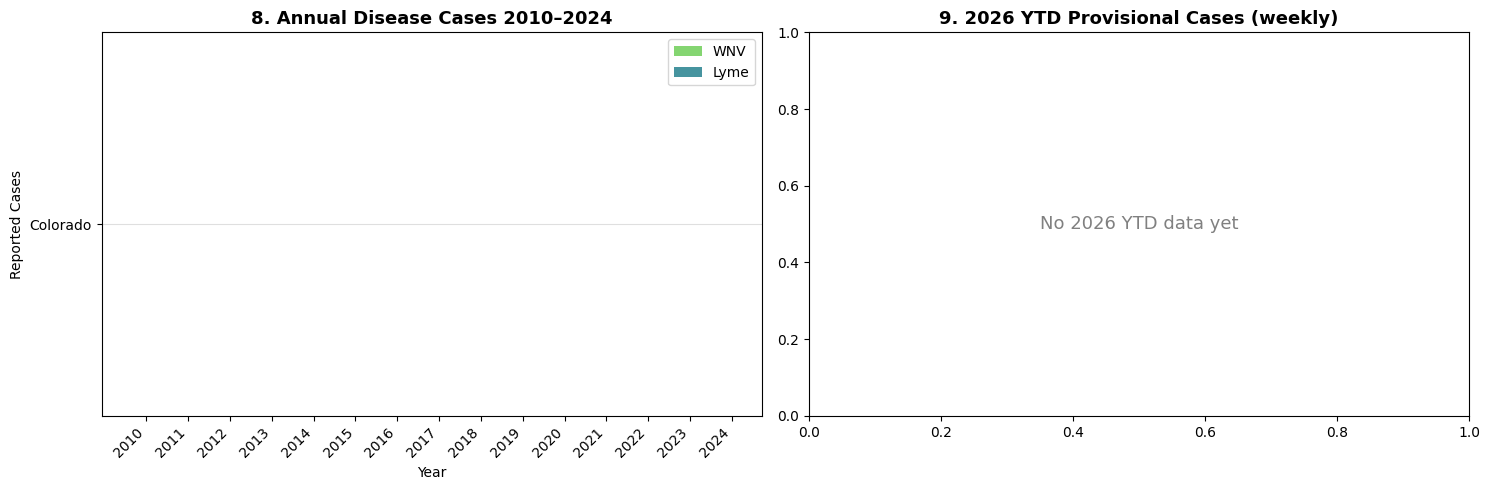


**Figure description (alt text):** Two panels: left shows annual WNV and Lyme case totals (2010-2024) as grouped bars. Right shows 2026 YTD cumulative cases by epi week.


In [7]:
"""Cell 7 — Case panels 8–9 (Matplotlib bar charts)."""
if not have_hist_cases:
    print("DEBUG: no historical case data — skipping panel 8")
else:
    fig2, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Panel 8: annual case totals 2010–2024
    ax = axes[0]
    ax.set_title("8. Annual Disease Cases 2010–2024", fontsize=13, fontweight="bold")
    legend_handles = []
    datasets = []
    if wnv_cases is not None and not wnv_cases.empty:
        yc = "year" if "year" in wnv_cases.columns else wnv_cases.columns[0]
        cc = "cases" if "cases" in wnv_cases.columns else wnv_cases.columns[1]
        d = wnv_cases.groupby(yc)[cc].sum().sort_index()
        datasets.append((d, "WNV", VIRIDIS[7]))
    if lyme_cases is not None and not lyme_cases.empty:
        yc = "year" if "year" in lyme_cases.columns else lyme_cases.columns[0]
        cc = "cases" if "cases" in lyme_cases.columns else lyme_cases.columns[1]
        d = lyme_cases.groupby(yc)[cc].sum().sort_index()
        datasets.append((d, "Lyme", VIRIDIS[4]))
    width = 0.35 / max(len(datasets), 1)
    for di, (d, label, color) in enumerate(datasets):
        offset = (di - len(datasets) / 2 + 0.5) * 0.35
        bars = ax.bar([x + offset for x in range(len(d))], d.values,
                      width=width*2, label=label, color=color, alpha=0.85)
        legend_handles.append(bars)
    ax.set_xlabel("Year")
    ax.set_ylabel("Reported Cases")
    if datasets:
        ax.set_xticks(range(len(datasets[0][0])))
        ax.set_xticklabels([str(y) for y in datasets[0][0].index], rotation=45, ha="right")
    ax.legend()
    ax.grid(axis="y", alpha=0.4)

    # Panel 9: current-year YTD
    ax2 = axes[1]
    ax2.set_title(f"9. {YEAR} YTD Provisional Cases (weekly)", fontsize=13, fontweight="bold")
    ytd_datasets = []
    if wnv_ytd is not None and not wnv_ytd.empty:
        wk_col = [c for c in wnv_ytd.columns if "week" in c.lower() or "epiweek" in c.lower()]
        ca_col = [c for c in wnv_ytd.columns if "count" in c.lower() or "cases" in c.lower()]
        if wk_col and ca_col:
            ytd_datasets.append((wnv_ytd, wk_col[0], ca_col[0], "WNV YTD", VIRIDIS[7]))
    if lyme_ytd is not None and not lyme_ytd.empty:
        wk_col = [c for c in lyme_ytd.columns if "week" in c.lower() or "epiweek" in c.lower()]
        ca_col = [c for c in lyme_ytd.columns if "count" in c.lower() or "cases" in c.lower()]
        if wk_col and ca_col:
            ytd_datasets.append((lyme_ytd, wk_col[0], ca_col[0], "Lyme YTD", VIRIDIS[4]))
    if ytd_datasets:
        for df_, wk, ca, label, color in ytd_datasets:
            ax2.plot(df_[wk], df_[ca].cumsum(), label=label, color=color, linewidth=2, marker="o", markersize=3)
        ax2.set_xlabel("Epi Week")
        ax2.set_ylabel("Cumulative Cases (YTD)")
        ax2.legend()
        ax2.grid(alpha=0.4)
    else:
        ax2.text(0.5, 0.5, f"No {YEAR} YTD data yet", ha="center", va="center",
                 transform=ax2.transAxes, fontsize=13, color="gray")

    plt.tight_layout()
        # Export data tables alongside chart
    import os
    if wnv_cases is not None and not wnv_cases.empty:
        wnv_cases.to_csv('nb08_wnv_annual_cases.csv', index=False)
        print('  → nb08_wnv_annual_cases.csv')
    if lyme_cases is not None and not lyme_cases.empty:
        lyme_cases.to_csv('nb08_lyme_annual_cases.csv', index=False)
        print('  → nb08_lyme_annual_cases.csv')
    if wnv_ytd is not None and not wnv_ytd.empty:
        wnv_ytd.to_csv('nb08_wnv_ytd.csv', index=False)
        print('  → nb08_wnv_ytd.csv')
    if lyme_ytd is not None and not lyme_ytd.empty:
        lyme_ytd.to_csv('nb08_lyme_ytd.csv', index=False)
        print('  → nb08_lyme_ytd.csv')
    plt.savefig("nb08_case_panels.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"\n**Figure description (alt text):** Two panels: left shows annual WNV and Lyme case totals (2010-2024) as grouped bars. Right shows {YEAR} YTD cumulative cases by epi week.")


In [8]:
"""Cell 8 — Panel 10: Integrated risk score with 95% CI (Plotly)."""
if not have_risk:
    print("DEBUG: risk data unavailable — skipping panel 10")
else:
    risk_dates = risk_s.index
    risk_color = RISK_COLORS.get(risk_label, "#a0aec0")

    fig3 = go.Figure()
    # Uncertainty band
    fig3.add_trace(go.Scatter(
        x=list(risk_dates) + list(risk_dates[::-1]),
        y=list(ci_high.values) + list(ci_low.values[::-1]),
        fill="toself",
        fillcolor="rgba(66,133,244,0.15)",
        line=dict(color="rgba(255,255,255,0)"),
        name="95% CI",
        hoverinfo="skip",
    ))
    # Central estimate
    fig3.add_trace(go.Scatter(
        x=risk_dates, y=risk_s.values,
        name="Integrated risk",
        line=dict(color=risk_color, width=2.5),
        hovertemplate="%{x|%b %d}: %{y:.3f}",
    ))
    fig3.add_hline(y=0.25, line_dash="dot", line_color="#ed8936",
                   annotation_text="Moderate threshold", annotation_position="bottom right")
    fig3.add_hline(y=0.60, line_dash="dot", line_color="#e53e3e",
                   annotation_text="High threshold", annotation_position="bottom right")

    fig3.update_layout(
        title_text=f"10. Integrated One Health Risk Score — {TODAY} | Category: {risk_label}",
        title_font_size=15,
        xaxis_title="Date",
        yaxis_title="Risk Score (0–1)",
        yaxis_range=[0, 1],
        height=380,
        legend=dict(orientation="h", y=-0.2),
        paper_bgcolor="white",
        plot_bgcolor="#f9fafb",
        font=dict(size=12),
    )
    fig3.show()
    current_val = float(risk_s.iloc[-1])
    ci_l_val = float(ci_low.iloc[-1])
    ci_h_val = float(ci_high.iloc[-1])
    print(f"\nPanel 10 alt text: Integrated risk score over 30 days. "
          f"Score={current_val:.3f} (95% CI {ci_l_val:.3f}–{ci_h_val:.3f}). "
          f"Category={risk_label}.")



Panel 10 alt text: Integrated risk score over 30 days. Score=nan (95% CI nan–nan). Category=nan.


## Data Sources & Accessibility Notes

| Panel | Data Source | Color Palette | Alt Text? |
|-------|-------------|---------------|-----------|
| 1–7   | NASA POWER (climate)  | Viridis (colorblind-safe) | ✓ below panel |
| 8     | CDC NNDSS historical  | Viridis                   | ✓ below panel |
| 9     | CDC provisional YTD   | Viridis                   | ✓ below panel |
| 10    | Module risk scorer    | Risk-level color          | ✓ below panel |

All interactive panels support keyboard navigation via Plotly.
Static panels (8–9) exported to  for embedding.
